In [1]:
import pandas as pd
import polars as pl
import pyarrow.dataset as ds

In [2]:
ruta_parquet_tomtom = 'data/raw/tomtom_move_reports/segments_1_to_31_aug_2024.parquet'
df_tomtom_lazy = pl.scan_parquet(ruta_parquet_tomtom)

df_tomtom = df_tomtom_lazy.collect()
df_tomtom.head(20)

date,station_id,station_name,segment_id,new_segment_id,frc,street_name,distance_m,time_set_id,hour_start,hour_end,harmonic_avg_speed,median_speed,avg_speed,std_speed,travel_time_std,sample_size,normalized_sample_size,avg_travel_time,median_travel_time,travel_time_ratio,speed_percentiles,geometry_wkt
str,i64,str,i64,str,i64,str,f64,i64,i64,i64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,list[i64],str
"""2024-08-01""",0,"""CENTRO""",-14840000675661,"""-00004d30-3900-0400-0000-00000…",5,"""Calle Tlaxcala""",82.01,2,0,1,23.6,24.7,24.3,3.9,2.56,9,0.0059,12.53,11.95,1.0,"[16, 16, … 29]","""LINESTRING (-100.3201 25.66233…"
"""2024-08-01""",0,"""CENTRO""",-14840000675661,"""-00004d30-3900-0400-0000-00000…",5,"""Calle Tlaxcala""",82.01,3,1,2,26.6,25.6,28.6,8.2,3.02,10,0.0065,11.1,11.53,0.89,"[19, 19, … 44]","""LINESTRING (-100.3201 25.66233…"
"""2024-08-01""",0,"""CENTRO""",-14840000675661,"""-00004d30-3900-0400-0000-00000…",5,"""Calle Tlaxcala""",82.01,4,2,3,25.8,28.2,29.3,10.3,4.96,8,0.0052,11.45,10.47,0.91,"[13, 13, … 47]","""LINESTRING (-100.3201 25.66233…"
"""2024-08-01""",0,"""CENTRO""",-14840000675661,"""-00004d30-3900-0400-0000-00000…",5,"""Calle Tlaxcala""",82.01,5,3,4,9.4,9.4,9.4,0.0,0.0,1,0.0007,31.41,31.41,2.51,"[9, 9, … 9]","""LINESTRING (-100.3201 25.66233…"
"""2024-08-01""",0,"""CENTRO""",-14840000675661,"""-00004d30-3900-0400-0000-00000…",5,"""Calle Tlaxcala""",82.01,6,4,5,18.2,17.2,18.7,4.0,3.15,3,0.002,16.23,17.16,1.3,"[16, 16, … 23]","""LINESTRING (-100.3201 25.66233…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2024-08-01""",0,"""CENTRO""",-14840000675661,"""-00004d30-3900-0400-0000-00000…",5,"""Calle Tlaxcala""",82.01,17,15,16,20.3,24.5,24.4,9.4,10.8,76,0.0496,14.53,12.05,1.16,"[12, 14, … 37]","""LINESTRING (-100.3201 25.66233…"
"""2024-08-01""",0,"""CENTRO""",-14840000675661,"""-00004d30-3900-0400-0000-00000…",5,"""Calle Tlaxcala""",82.01,18,16,17,18.8,21.9,21.4,6.6,7.62,95,0.062,15.72,13.48,1.25,"[10, 13, … 30]","""LINESTRING (-100.3201 25.66233…"
"""2024-08-01""",0,"""CENTRO""",-14840000675661,"""-00004d30-3900-0400-0000-00000…",5,"""Calle Tlaxcala""",82.01,19,17,18,17.3,21.3,20.7,7.3,9.29,169,0.1103,17.07,13.86,1.36,"[8, 11, … 31]","""LINESTRING (-100.3201 25.66233…"


Usar filtros en caso de que no cuentes con la suficiente memoria fisica

In [3]:
df_tomtom.estimated_size('gb')

11.231291579082608

In [4]:
ruta_csv_sima = "data/processed/df_imputados_saits_agosto2024_schema.csv"
df_sima = pl.read_csv(ruta_csv_sima)
# filtrar a solo agosto
df_sima = df_sima.filter(
    pl.col("date").str.to_datetime(format="%Y-%m-%d %H:%M:%S").dt.month() == 8,
     pl.col("date").str.to_datetime(format="%Y-%m-%d %H:%M:%S").dt.year() == 2024
)

In [5]:
df_sima

date,CO,O3,NO,NO2,PM2.5,NOX,PM10,SO2,WSR,WDR,Zona,Hora
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64
"""2024-08-01 00:00:00""",-1.424497,-0.581173,-0.483733,-0.613314,0.5517231,-0.546929,0.758908,-0.78657,0.357567,-0.336853,"""CENTRO""",0
"""2024-08-01 00:00:00""",-0.188631,-0.716617,-0.409241,-0.565063,0.03244,-0.477955,0.4903238,-0.296203,0.176211,0.500649,"""NORTE""",0
"""2024-08-01 00:00:00""",-1.12112,-0.476026,-0.48203,-0.917999,0.422972,-0.732387,1.0479414,-1.045984,0.7730779,-0.385658,"""SURESTE""",0
"""2024-08-01 01:00:00""",-1.307341,-0.793043,-0.281447,-0.341593,0.9982198,-0.305273,1.0044688,-0.698995,0.171995,-0.701005,"""CENTRO""",1
"""2024-08-01 01:00:00""",-0.21971,-0.667838,-0.437676,-0.718837,0.111575,-0.544024,0.27127,-0.006895,-0.140536,0.402739,"""NORTE""",1
…,…,…,…,…,…,…,…,…,…,…,…,…
"""2024-08-31 22:00:00""",0.8427421,-0.56607,-0.38752,0.7322222,-0.016848,-0.054657,-0.775322,-0.402268,-0.687515,-0.168488,"""NORTE""",22
"""2024-08-31 22:00:00""",-0.004613,-1.270482,0.4326014,1.618422,-1.005733,1.0353338,-0.272331,-0.963192,-1.10745,0.175888,"""SURESTE""",22
"""2024-08-31 23:00:00""",-0.731364,-0.841849,-0.468965,0.270383,-0.696515,-0.088179,-0.686773,-0.484303,-0.916907,-0.27868,"""CENTRO""",23


## Calculo de candidatos


In [6]:
df_tomtom = df_tomtom[['date', 'hour_start', 'station_name', 'segment_id', 'street_name', 'sample_size', 'travel_time_ratio', 'frc', 'avg_speed', 'distance_m', 'geometry_wkt']] # agrega columnas si lo requieres para calcular otra variable


# numero de muestras en la zona de la estacion
df_tomtom_suma_muestra = df_tomtom.group_by([
        'date',
        'hour_start',
        'station_name'
    ]).agg(
        pl.col('sample_size').sum().alias('total_sample_size_per_hour')
    ).sort(['station_name', 'date', 'hour_start'])

# avg_tti_street (de Ana Valverde)
df_tomtom_avg_tti_street = df_tomtom.filter(
    (pl.col("frc") <= 4)
    & (pl.col("sample_size") >= 10)
).group_by([
        'date',
        'hour_start',
        'station_name'
    ]).agg(
        pl.col("travel_time_ratio").mean().alias("avg_tti_street")
    ).sort(['station_name', 'date', 'hour_start'])


# Índice de Congestión Vehicular (de Rene)
import polars as pl

FRC_to_lanes = {
    0: 3,
    1: 2,
    2: 2,
    3: 2,
    4: 1,
    5: 1,
    6: 1,
    7: 1,
}

JAM_DENSITY_PER_LANE = 150

df_tomtom_vci_per_segment = (
    df_tomtom
    .with_columns(
        pl.col("frc").replace(FRC_to_lanes).alias("lanes")
    )
    .with_columns(
        pl.col("avg_speed").max().over("date").alias("free_flow_speed")
    )
    .with_columns(
        (JAM_DENSITY_PER_LANE * (1 - pl.col("avg_speed") / pl.col("free_flow_speed")))
        .alias("est_density_per_lane")
    )
    .with_columns(
        (pl.col("est_density_per_lane") * pl.col("lanes")).alias("est_density_total")
    )
    .with_columns(
        (pl.col("distance_m") / 1000).alias("distance_km")
    )
    .with_columns(
        (pl.col("est_density_total") * pl.col("distance_km"))
        .alias("estimated_vehicles_in_segment")
    )
    .with_columns(
        (pl.col("est_density_total") / (JAM_DENSITY_PER_LANE * pl.col("lanes")))
        .alias("congestion_ratio")
    ).with_columns(
        pl.col("geometry_wkt").alias("geometry_wkt")
    )
)

df_tomtom_vci_mean = (df_tomtom_vci_per_segment
                      .group_by([
                        'date',
                        'hour_start',
                        'station_name'
                    ]).agg(
                        pl.col("congestion_ratio").mean().alias("congestion_ratio_mean"))
                        .sort(['station_name', 'date', 'hour_start']))

# Índice de Congestión Vehicular (de Rene) REAL
df_ic_centro = pl.read_csv("data/processed/indice_congestion/df_station_centro_IDC.csv")
df_ic_norte = pl.read_csv("data/processed/indice_congestion/df_station_norte_IDC.csv")
df_ic_sureste = pl.read_csv("data/processed/indice_congestion/df_station_sureste_IDC.csv")

df_ic_centro = df_ic_centro.with_columns(
    pl.lit("CENTRO").alias("station_name")
)
df_ic_norte = df_ic_norte.with_columns(
    pl.lit("NORTE").alias("station_name")
)
df_ic_sureste = df_ic_sureste.with_columns(
    pl.lit("SURESTE").alias("station_name")
)

df_ic = pl.concat(
    [df_ic_centro,
    df_ic_norte,
    df_ic_sureste]
)

df_ic


date,hour_start,congestion_raw_sum,congestion_raw_mean,segment_count,station_name
str,i64,f64,f64,i64,str
"""2024-08-01""",0,114.562615,0.020109,5697,"""CENTRO"""
"""2024-08-01""",1,77.556966,0.0164,4729,"""CENTRO"""
"""2024-08-01""",2,70.581388,0.016533,4269,"""CENTRO"""
"""2024-08-01""",3,60.472245,0.016545,3655,"""CENTRO"""
"""2024-08-01""",4,68.723351,0.019191,3581,"""CENTRO"""
…,…,…,…,…,…
"""2024-08-31""",19,137.316199,0.027283,5033,"""SURESTE"""
"""2024-08-31""",20,144.964183,0.02828,5126,"""SURESTE"""
"""2024-08-31""",21,162.856797,0.032735,4975,"""SURESTE"""


In [16]:
df_tomtom_vci_per_segment.sample(1000).write_csv("df_tomtom_sample.csv")

## .

In [8]:
df_sima = df_sima.with_columns(
    pl.col("date").str.to_datetime(format="%Y-%m-%d %H:%M:%S").alias("date")
)
df_sima  = df_sima.with_columns(
    pl.col("date").dt.date().cast(pl.Utf8).alias("date_only")
)
df_sima = df_sima[['date_only', 'Hora', 'Zona', 'CO', 'NOX', 'O3', 'PM2.5', 'PM10']]
df_sima

date_only,Hora,Zona,CO,NOX,O3,PM2.5,PM10
str,i64,str,f64,f64,f64,f64,f64
"""2024-08-01""",0,"""CENTRO""",-1.424497,-0.546929,-0.581173,0.5517231,0.758908
"""2024-08-01""",0,"""NORTE""",-0.188631,-0.477955,-0.716617,0.03244,0.4903238
"""2024-08-01""",0,"""SURESTE""",-1.12112,-0.732387,-0.476026,0.422972,1.0479414
"""2024-08-01""",1,"""CENTRO""",-1.307341,-0.305273,-0.793043,0.9982198,1.0044688
"""2024-08-01""",1,"""NORTE""",-0.21971,-0.544024,-0.667838,0.111575,0.27127
…,…,…,…,…,…,…,…
"""2024-08-31""",22,"""NORTE""",0.8427421,-0.054657,-0.56607,-0.016848,-0.775322
"""2024-08-31""",22,"""SURESTE""",-0.004613,1.0353338,-1.270482,-1.005733,-0.272331
"""2024-08-31""",23,"""CENTRO""",-0.731364,-0.088179,-0.841849,-0.696515,-0.686773


In [9]:
df_sima_union_candidato = df_sima.join(
    df_tomtom_suma_muestra,
    left_on=['date_only', 'Hora', 'Zona'],
    right_on=['date', 'hour_start', 'station_name'],
    how='left'
)

df_sima_union_candidato = df_sima_union_candidato.join(
    df_tomtom_avg_tti_street,
    left_on=['date_only', 'Hora', 'Zona'],
    right_on=['date', 'hour_start', 'station_name'],
    how='left'
)

df_sima_union_candidato = df_sima_union_candidato.join(
    df_tomtom_vci_mean,
    left_on=['date_only', 'Hora', 'Zona'],
    right_on=['date', 'hour_start', 'station_name'],
    how='left'
)

df_sima_union_candidato = df_sima_union_candidato.join(
    df_ic,
    left_on=['date_only', 'Hora', 'Zona'],
    right_on=['date', 'hour_start', 'station_name'],
    how='left'
)

df_sima_union_candidato

date_only,Hora,Zona,CO,NOX,O3,PM2.5,PM10,total_sample_size_per_hour,avg_tti_street,congestion_ratio_mean,congestion_raw_sum,congestion_raw_mean,segment_count
str,i64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64
"""2024-08-01""",0,"""CENTRO""",-1.424497,-0.546929,-0.581173,0.5517231,0.758908,189688,1.0,0.888761,114.562615,0.020109,5697
"""2024-08-01""",0,"""NORTE""",-0.188631,-0.477955,-0.716617,0.03244,0.4903238,35408,1.0,0.954203,72.97149,0.02133,3421
"""2024-08-01""",0,"""SURESTE""",-1.12112,-0.732387,-0.476026,0.422972,1.0479414,82071,1.0,0.934999,85.316426,0.026645,3202
"""2024-08-01""",1,"""CENTRO""",-1.307341,-0.305273,-0.793043,0.9982198,1.0044688,103179,0.983412,0.899864,77.556966,0.0164,4729
"""2024-08-01""",1,"""NORTE""",-0.21971,-0.544024,-0.667838,0.111575,0.27127,20469,0.967393,0.958459,74.184452,0.024016,3089
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2024-08-31""",22,"""NORTE""",0.8427421,-0.054657,-0.56607,-0.016848,-0.775322,110445,1.187061,0.940748,167.285863,0.033067,5059
"""2024-08-31""",22,"""SURESTE""",-0.004613,1.0353338,-1.270482,-1.005733,-0.272331,257814,1.289344,0.925627,135.619613,0.028278,4796
"""2024-08-31""",23,"""CENTRO""",-0.731364,-0.088179,-0.841849,-0.696515,-0.686773,505461,1.070079,0.883681,110.985254,0.016622,6677


In [10]:
# Remover fines de semana

df_sima_union_candidato = df_sima_union_candidato.filter(
    (pl.col('date_only').str.to_datetime(format="%Y-%m-%d").dt.weekday() != 6) &
    (pl.col('date_only').str.to_datetime(format="%Y-%m-%d").dt.weekday() != 7)
)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
def plot_candidate_v_contaminant(df ,candidate, contaminant):

    plt.figure(figsize=(10, 6))

    sns.regplot(
        x=candidate,
        y=contaminant,
        data=df.to_pandas(),
        scatter_kws={'alpha': 0.5},
        line_kws={'color': 'red', 'lw': 2}
    )

    mean_contaminant = df[contaminant].mean()

    plt.axhline(
        y=mean_contaminant,
        color='blue',
        linestyle='--',
        linewidth=2,
        label=f'Media de {contaminant}: {mean_contaminant:.2f}'
    )

    plt.title(f'Scatterplot de {candidate} vs {contaminant} en {df["Zona"][0]}')
    plt.xlabel(candidate)
    plt.ylabel(contaminant)
    plt.legend()
    plt.grid(True)

    plt.show()

In [13]:
def plot_centros_candidate_v_contamintant(df, candidate, contaminant):
    df_sima_union_candidato_norte = df.filter(pl.col('Zona') == "NORTE")
    df_sima_union_candidato_sureste = df.filter(pl.col('Zona') == "SURESTE")
    df_sima_union_candidato_centro = df.filter(pl.col('Zona') == "CENTRO")
    plot_candidate_v_contaminant(df_sima_union_candidato_norte, candidate, contaminant)
    plot_candidate_v_contaminant(df_sima_union_candidato_sureste, candidate, contaminant)
    plot_candidate_v_contaminant(df_sima_union_candidato_centro, candidate, contaminant)

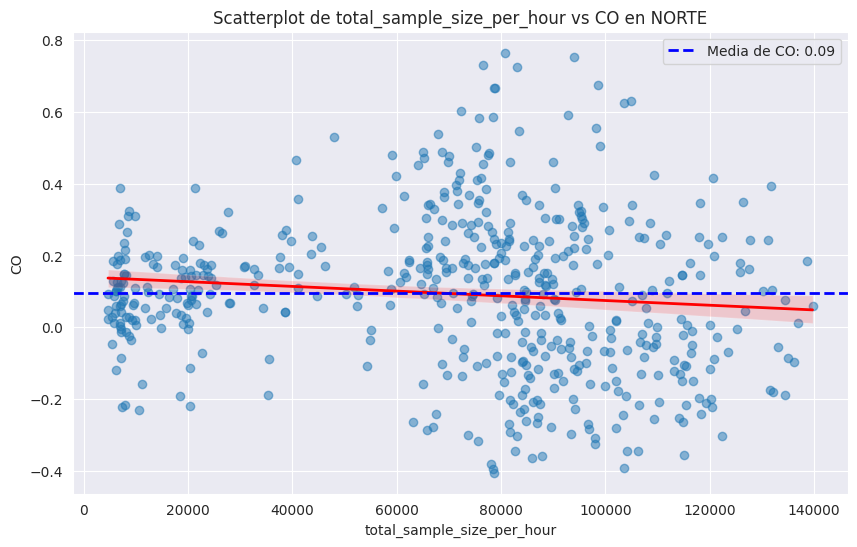

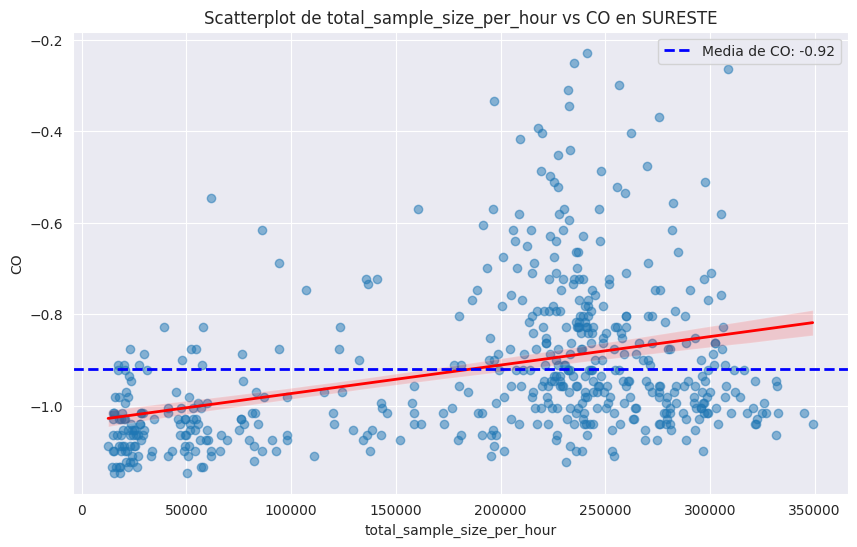

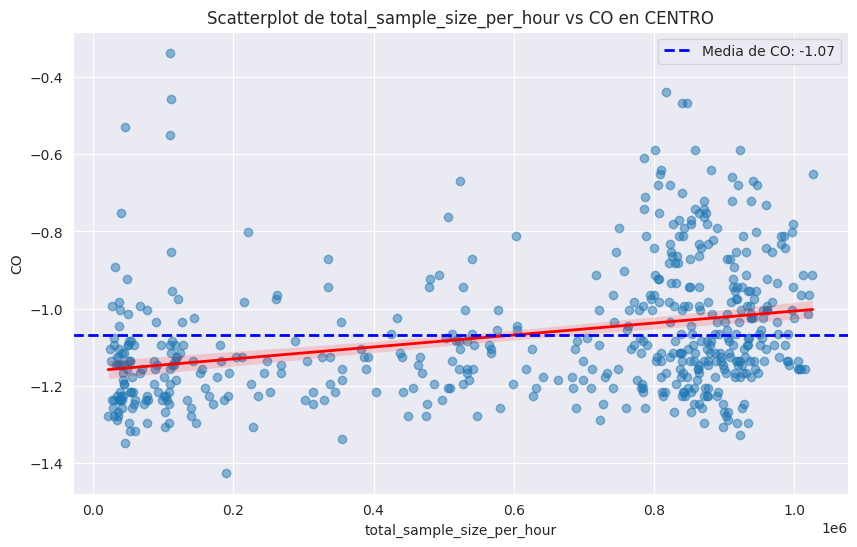

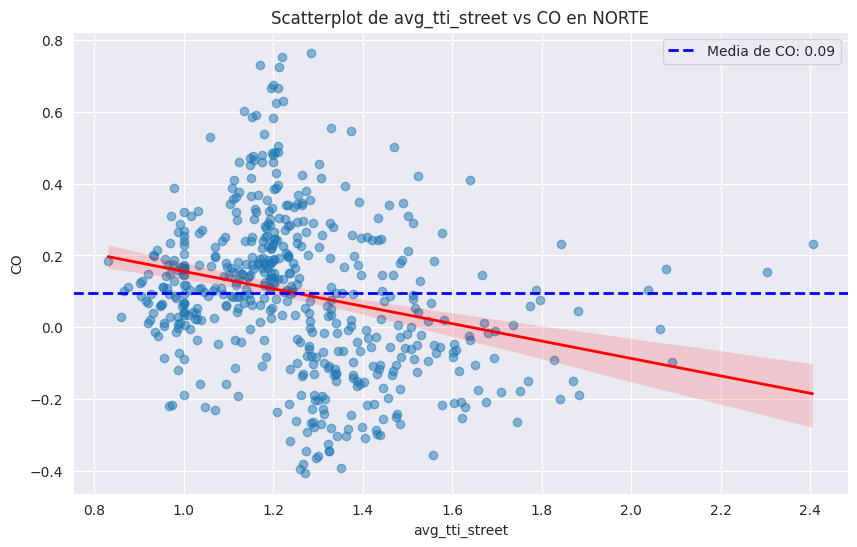

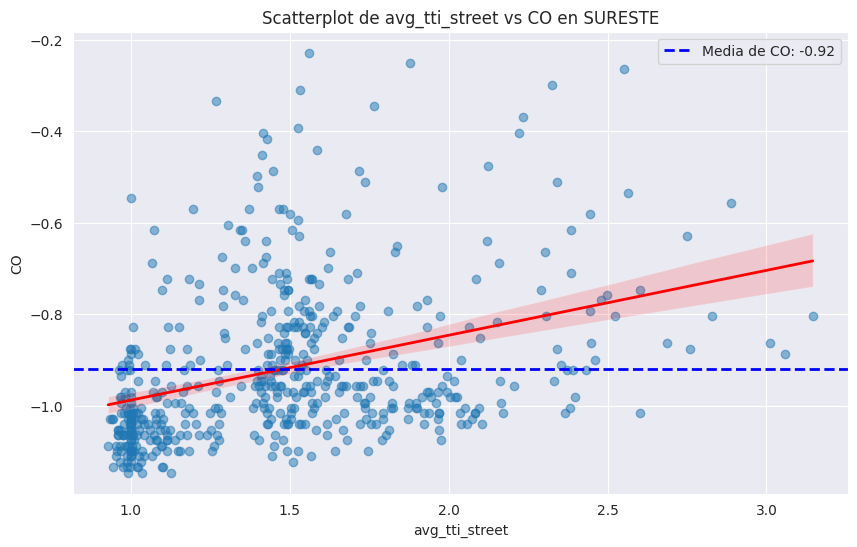

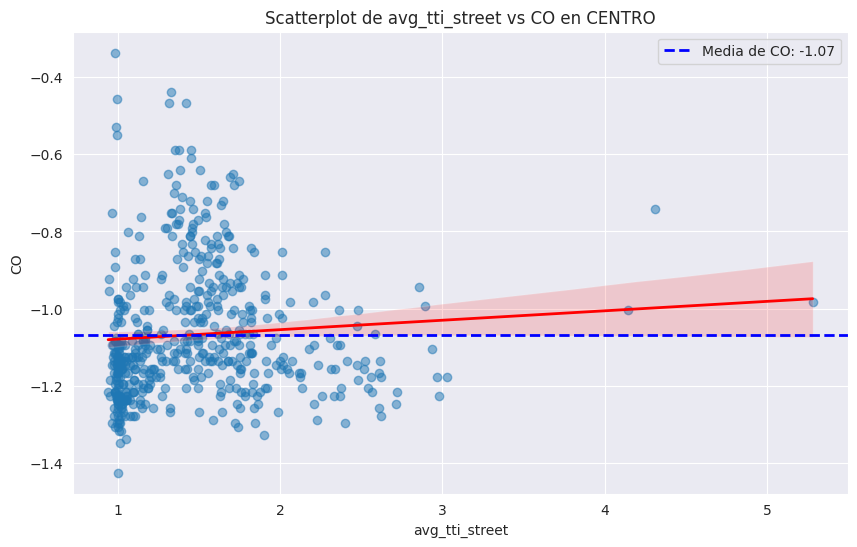

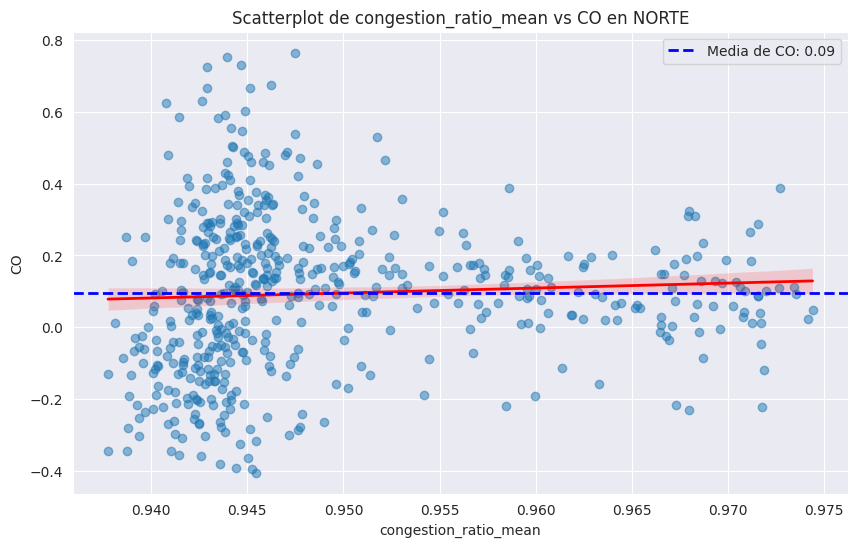

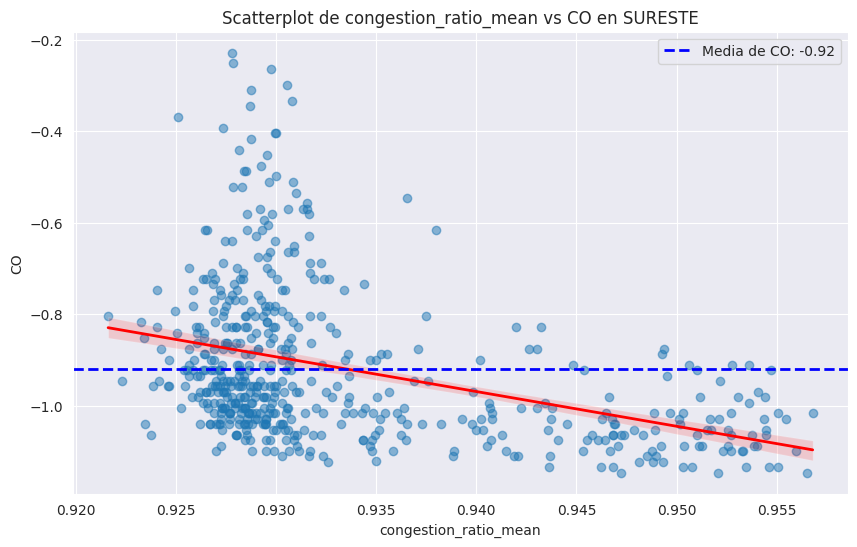

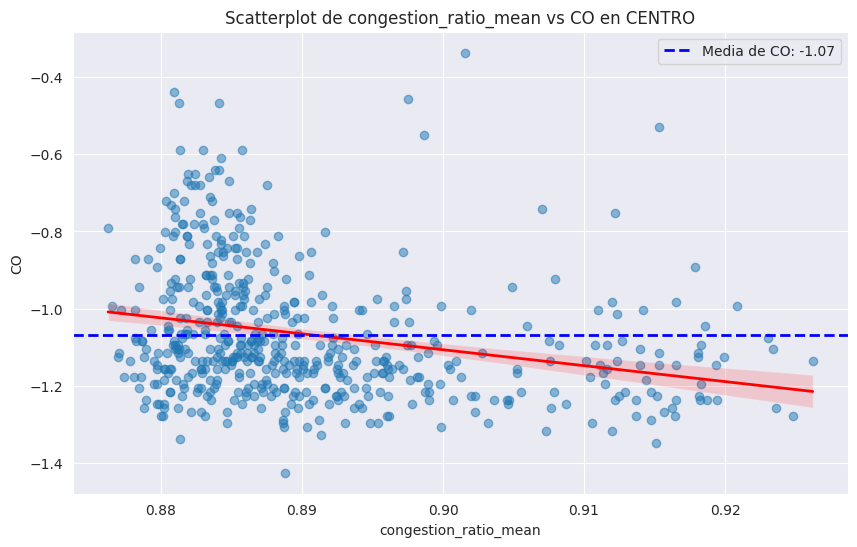

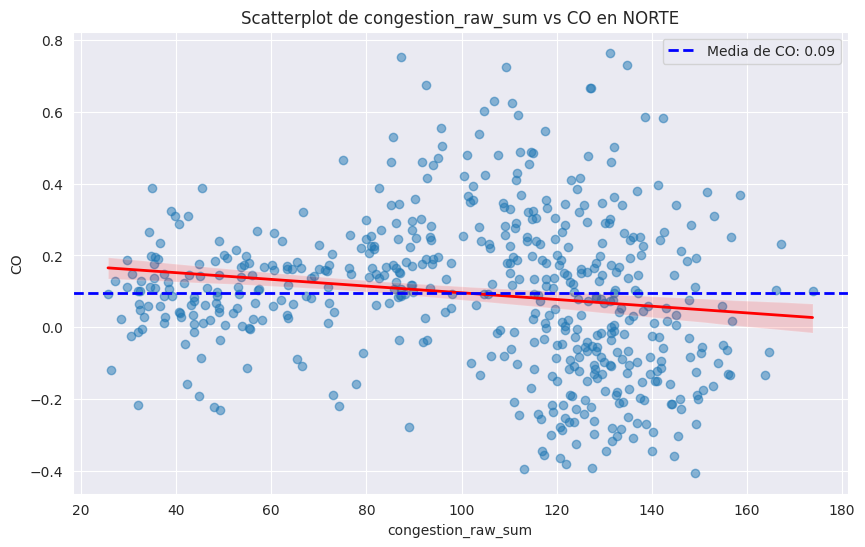

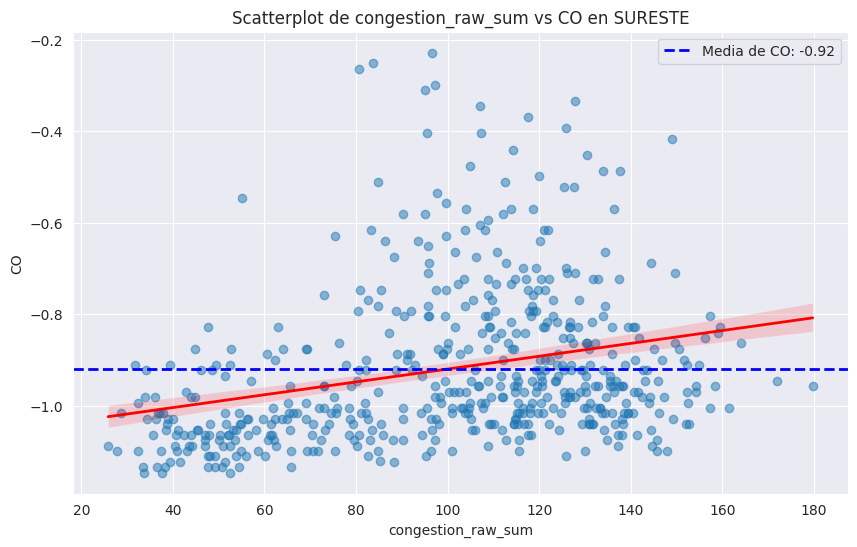

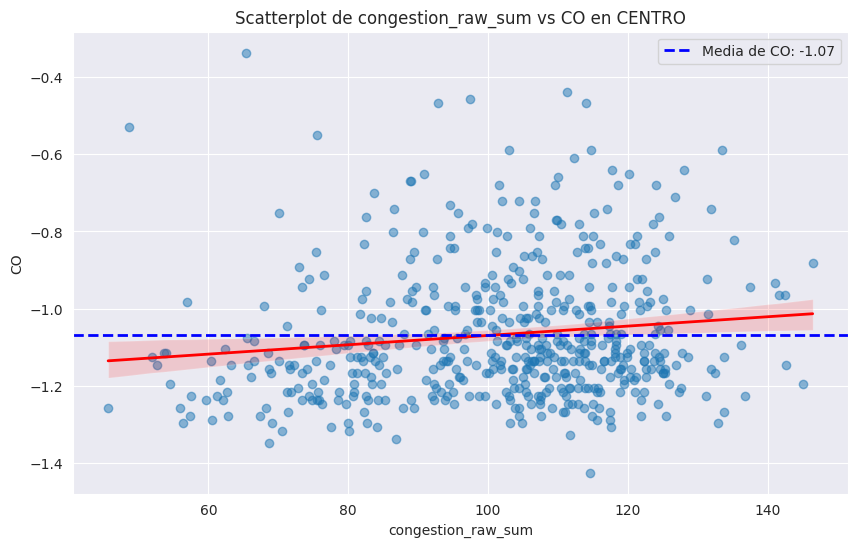

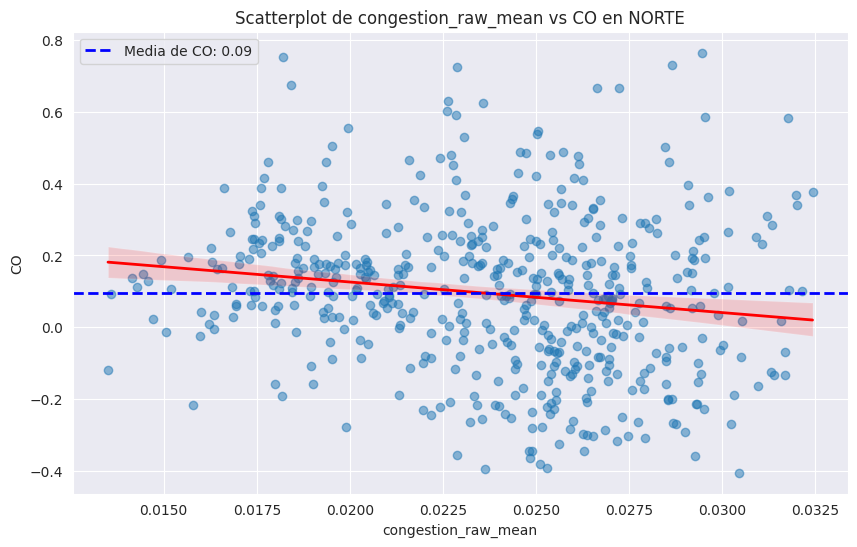

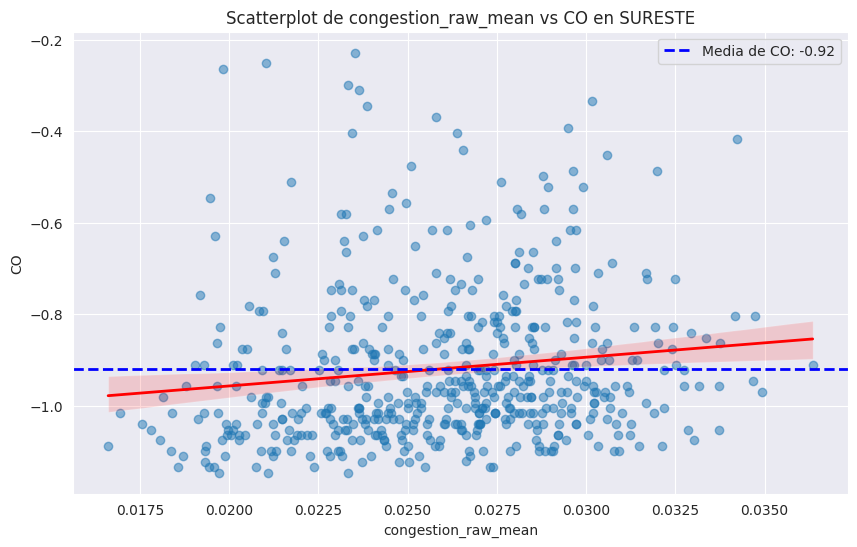

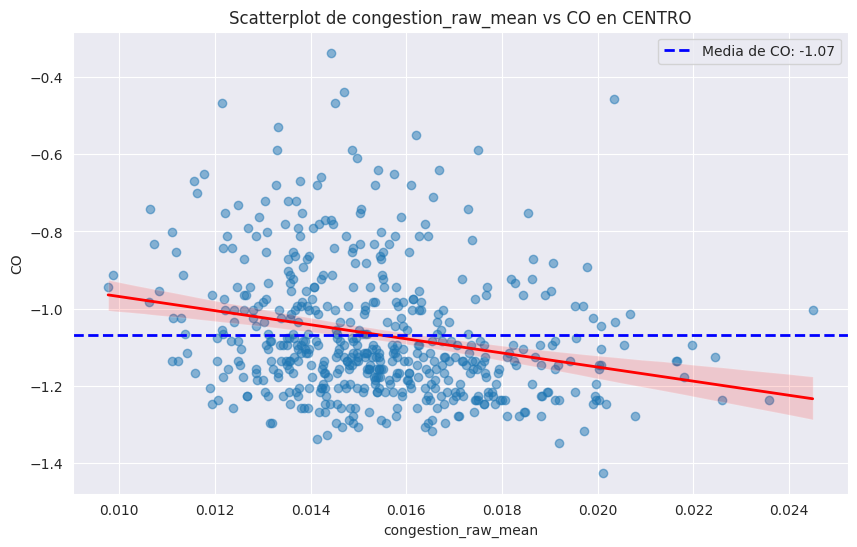

In [14]:
plot_centros_candidate_v_contamintant(df_sima_union_candidato, 'total_sample_size_per_hour', 'CO')
plot_centros_candidate_v_contamintant(df_sima_union_candidato, 'avg_tti_street', 'CO')
plot_centros_candidate_v_contamintant(df_sima_union_candidato, 'congestion_ratio_mean', 'CO')
plot_centros_candidate_v_contamintant(df_sima_union_candidato, 'congestion_raw_sum', 'CO')
plot_centros_candidate_v_contamintant(df_sima_union_candidato, 'congestion_raw_mean', 'CO')

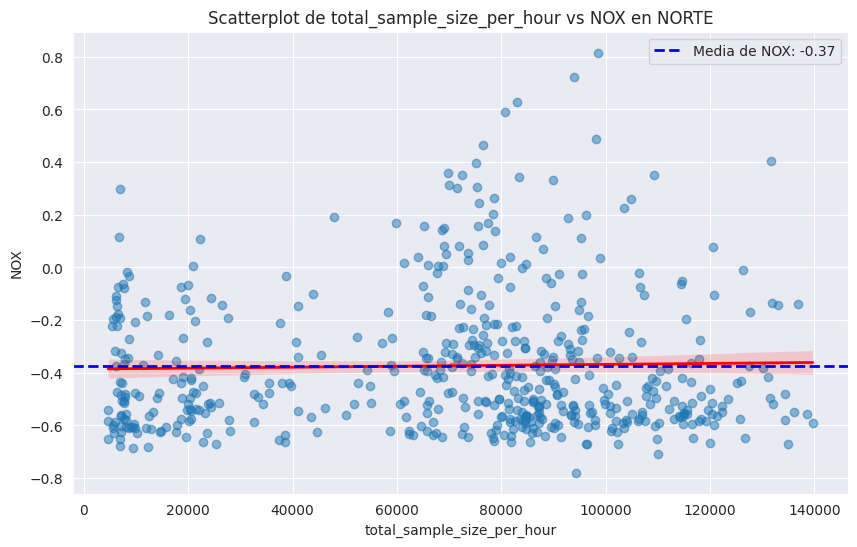

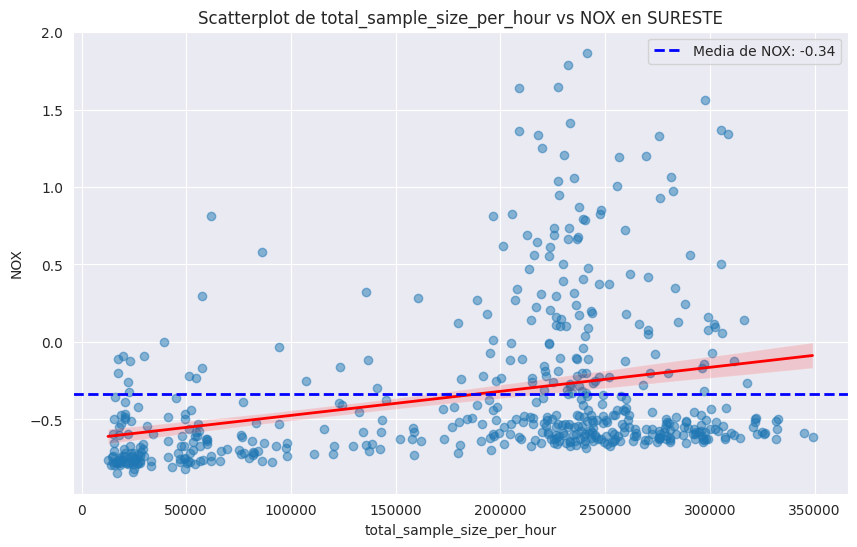

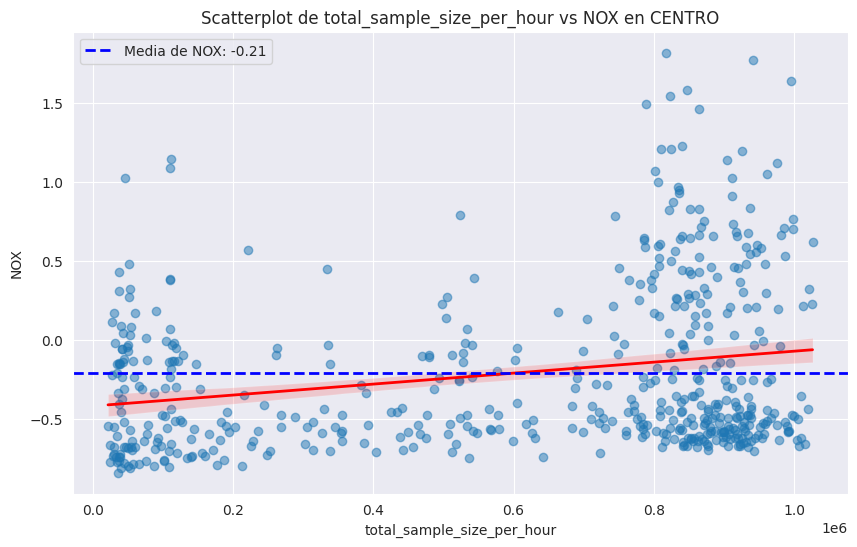

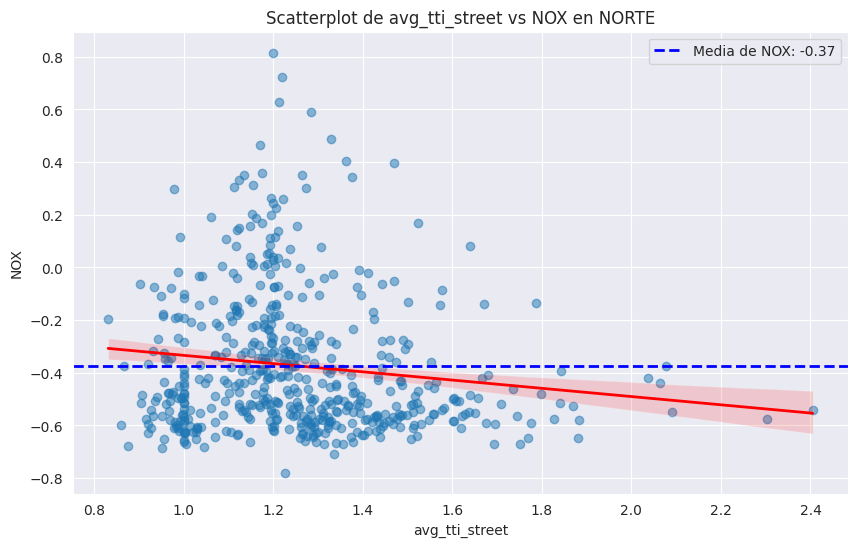

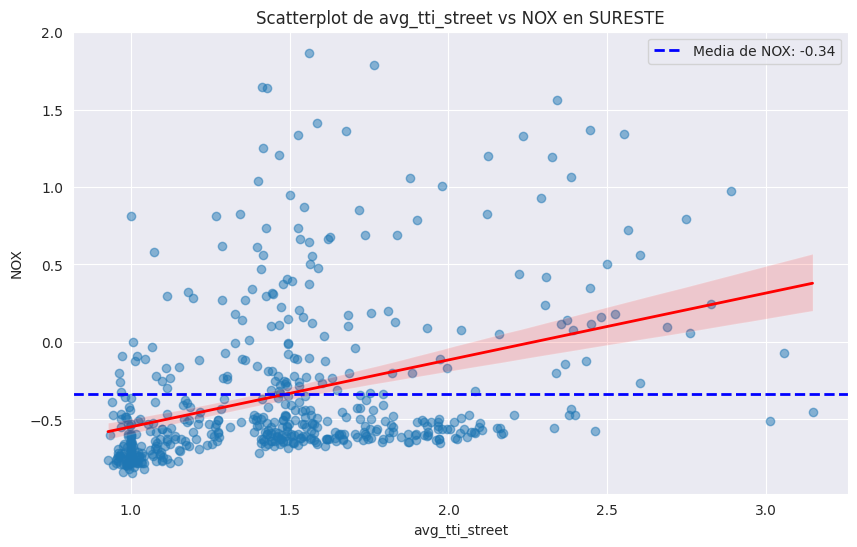

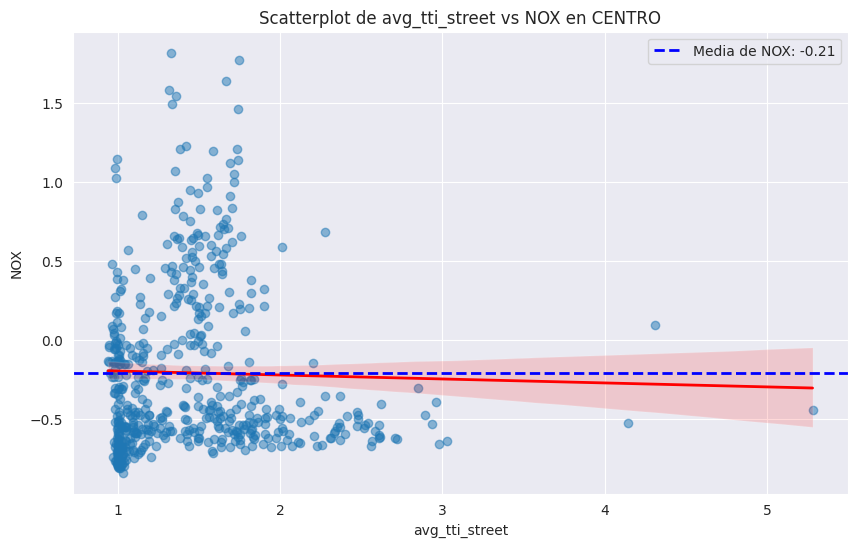

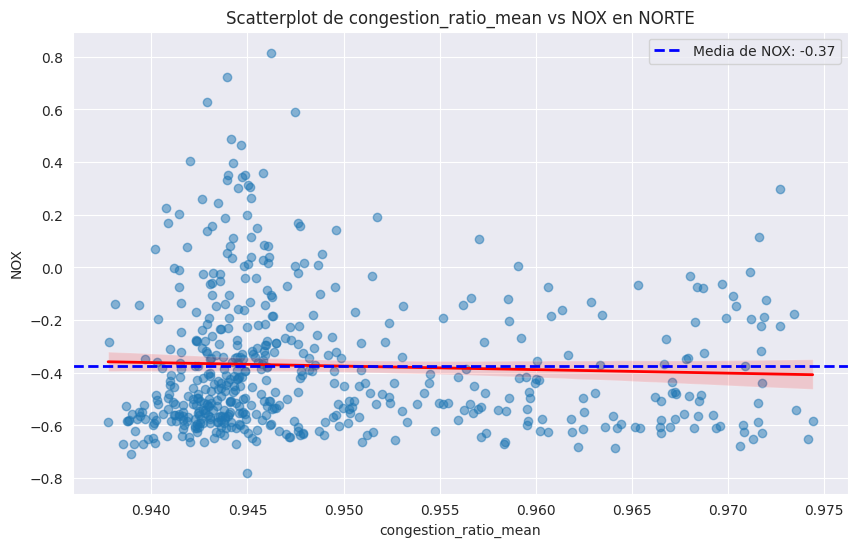

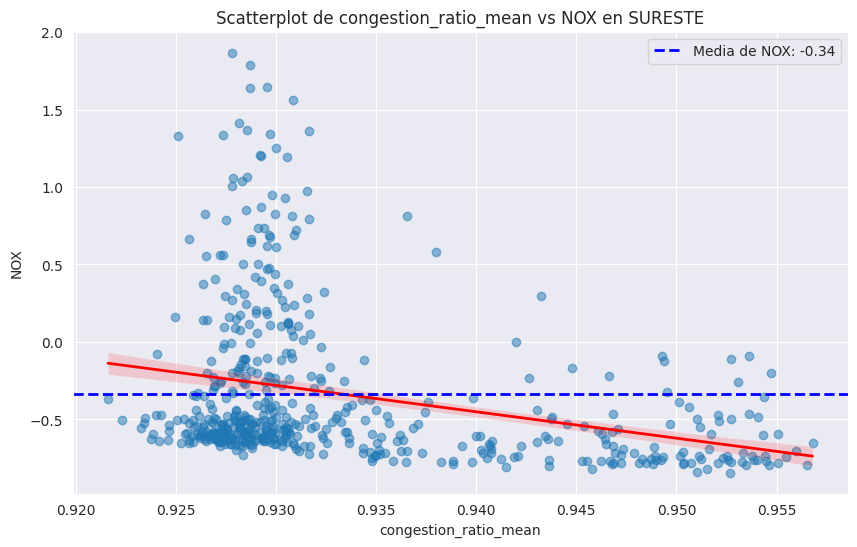

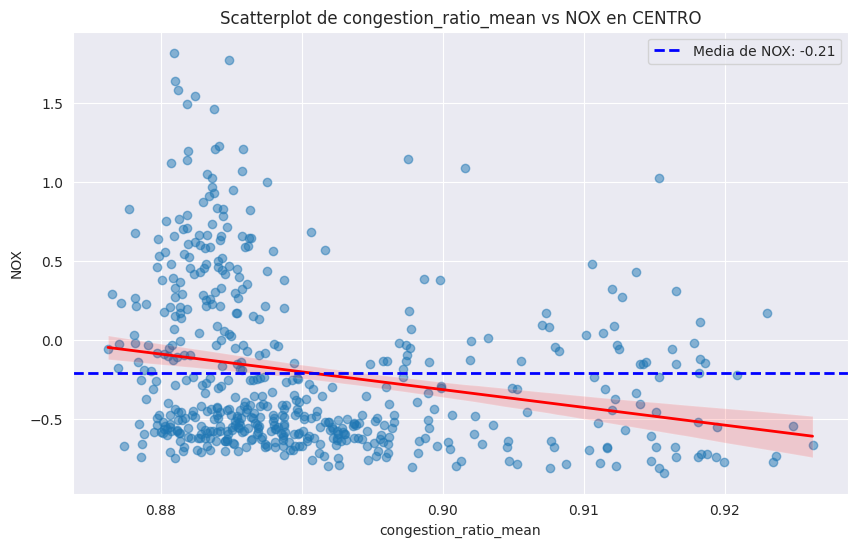

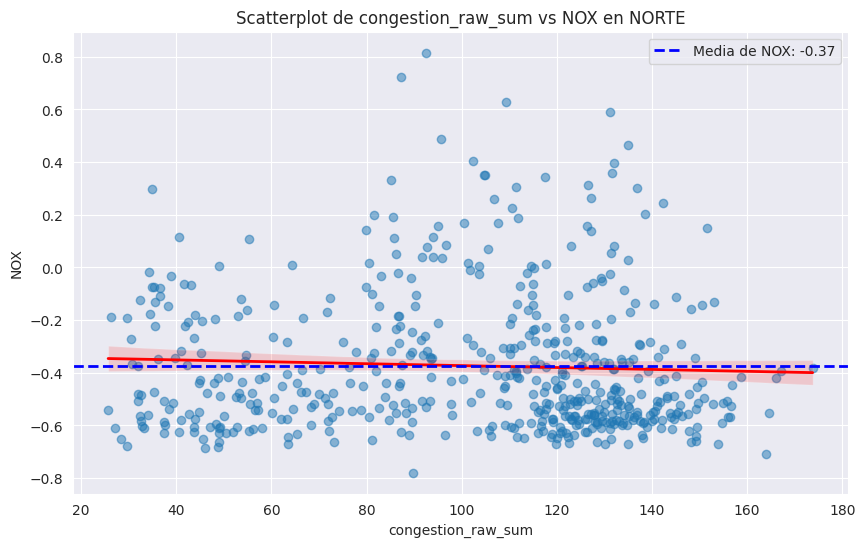

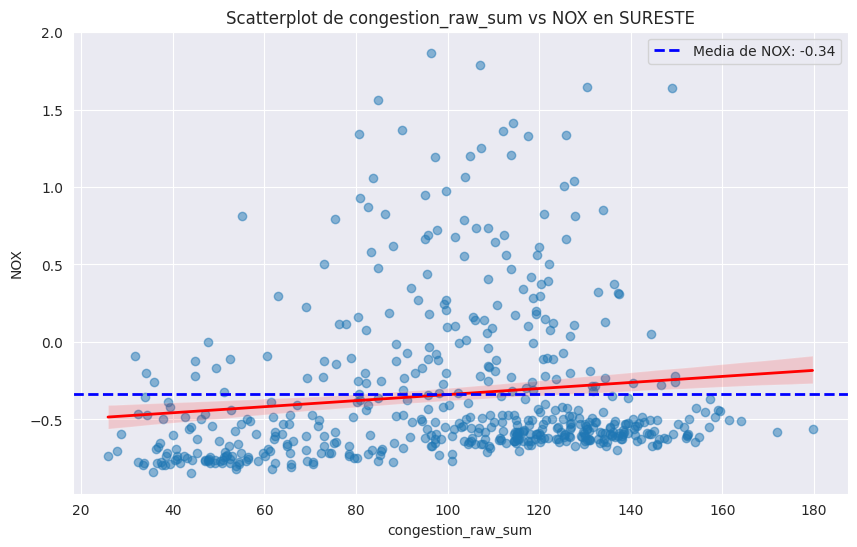

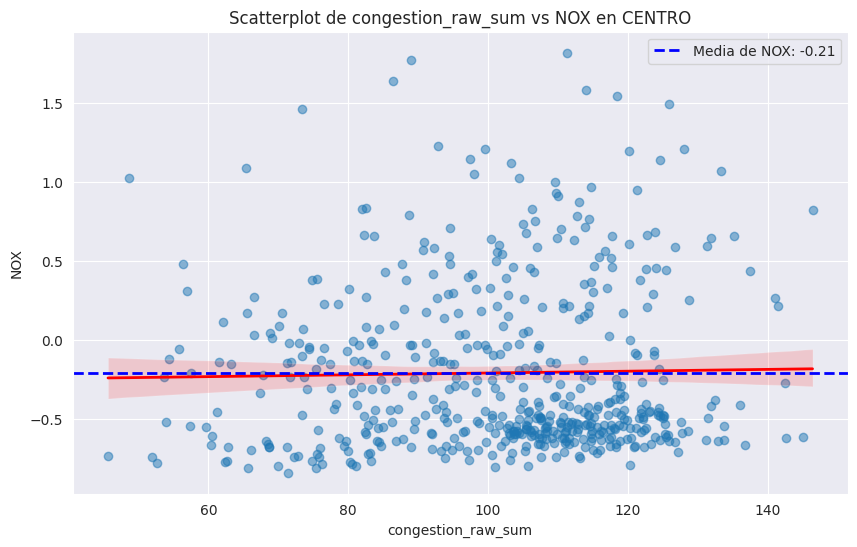

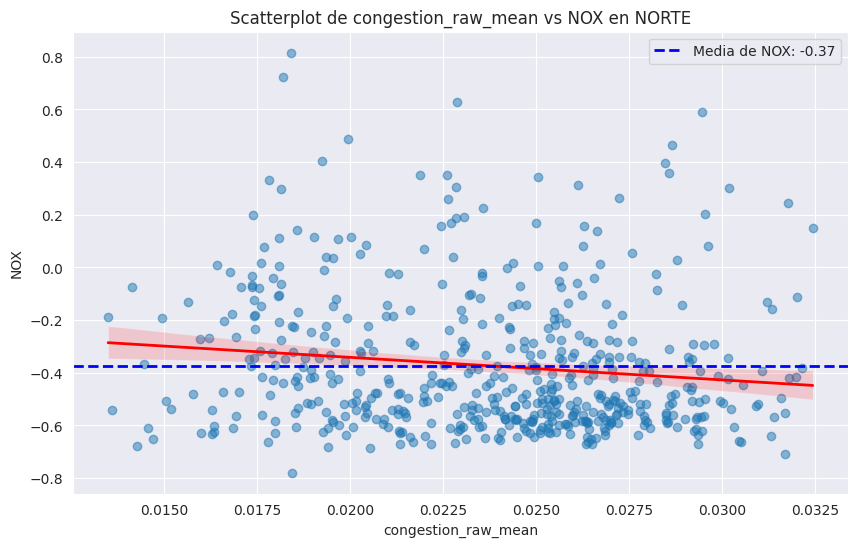

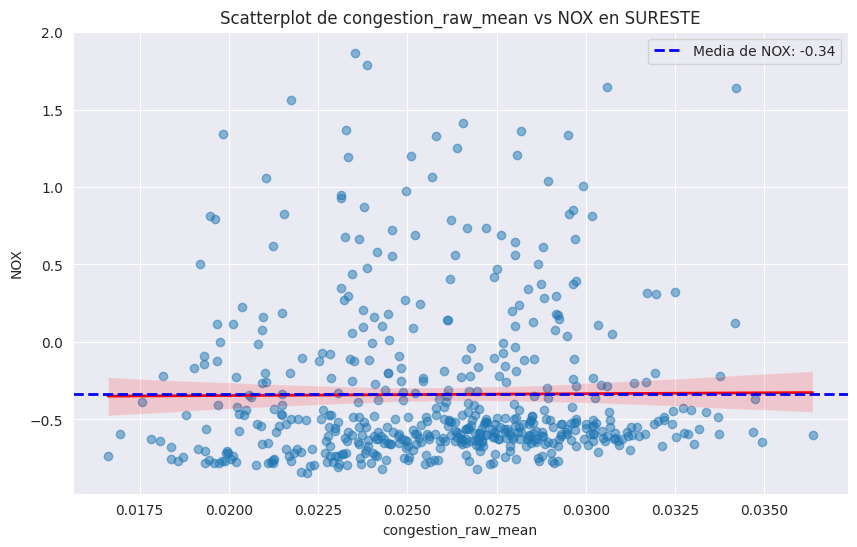

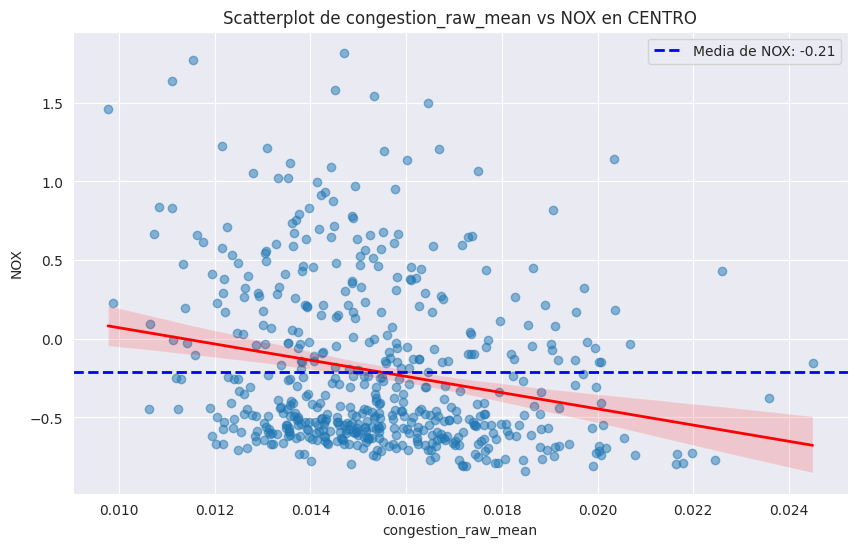

In [15]:
plot_centros_candidate_v_contamintant(df_sima_union_candidato, 'total_sample_size_per_hour', 'NOX')
plot_centros_candidate_v_contamintant(df_sima_union_candidato, 'avg_tti_street', 'NOX')
plot_centros_candidate_v_contamintant(df_sima_union_candidato, 'congestion_ratio_mean', 'NOX')
plot_centros_candidate_v_contamintant(df_sima_union_candidato, 'congestion_raw_sum', 'NOX')
plot_centros_candidate_v_contamintant(df_sima_union_candidato, 'congestion_raw_mean', 'NOX')